### Wikidata Preprocessing

#### Data Source
First, we take the GLDv2 dataset and merge the train and index csv.

For each landmark, we find the relevant wikimedia url (available on GLDv2 repo as well).

We remove records that doesn't have valid wikimedia url.

#### Metadata Mining
We collect additional metadata from the wikimedia url such as: latitude, longitude, P31 instance of tags, and landmark name.

We then remove the records that doesn't have valid latitude, longitude, and P31 tags.

#### P31 Tags Processing
The nature of P31 tags are very diverse and sometimes very specific (fine-grained) that we believe quite rare to be mentioned in user query.

Therefore, we attempt to flatten and group them by generating coarser taxonomy.

Our approach quite straightforward:
- First, we leverage BERTopic to identify clusters among the tags.
- Instead of taking the cTF-IDF keywords from BERTopic to represent the clusters, we pair the original tags with topic labels.
- We then feed the representative tags to LLM to generate 3 keywords candidate to represent the cluster.
- Finally, we ask human validator to select one keyword that best representing the topic/cluster.

##### Postprocessing
HDBSCAN will flag the outlier tags and assign class of `-1` to them.

To mitigate this, we measure the distance between each cluster centroid embedding and each individual tag that flagged as outlier.

Specifically, we take the average of tag embeddings from each cluster. We later call this as cluster centroid embedding.

Then, we compare each one of tag embedding with class of `-1` with all cluster centroid embedding.

We then assign the cluster class to its nearest centroid embedding.

In [1]:
from collections import Counter

import hdbscan
import numpy as np
import polars as pl
import torch
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
df = pl.read_csv("../../datasets/google-landmark/raw_train_index.csv")
df_tag_clean = df.with_columns(
    pl.col("instance_tag").str.split(",").alias("instance_tag")
).with_columns(
    pl.col("instance_tag")
    .list.eval(
        pl.element().filter(
            ~pl.element().is_in(["Wikimedia category"])
            & ~pl.element().str.contains(r"^Q\d+$")
        )
    )
    .alias("instance_tag_clean")
)

In [3]:
flatten_tags = []
for tag in df_tag_clean.unique("wikimedia_url")["instance_tag_clean"].to_list():
    for t in tag:
        flatten_tags.append(t)

ctags = Counter(flatten_tags)
tags = list(ctags.keys())

#### UMAP + HDBSCAN + Agglomerative Clustering (TBC | WIP)

In [179]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2").to(DEVICE)
# model = SentenceTransformer(
#     "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# ).to(DEVICE)
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
).to(DEVICE)
reductor = UMAP(metric="cosine", n_components=15, random_state=42)

MIN_CLUSTER_SIZES = [5, 10, 15, 20, 25, 50, 100]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
tag_embeddings = model.encode(tags)
r_tag_embeddings = reductor.fit_transform(tag_embeddings).astype(np.float64)

In [ ]:
def tune_hdbscan(reduced_embeddings, min_cluster_sizes):
    results = []
    for size in min_cluster_sizes:
        clusterer = HDBSCAN(min_cluster_size=size).fit(reduced_embeddings)
        labels = clusterer.labels_
        score = hdbscan.validity.validity_index(reduced_embeddings, labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1) * 100
        results.append(
            {
                "min_cluster_size": size,
                "dbcv": score,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "clf": clusterer,
            }
        )
        print(
            f"Min Cluster Size: {size} -> DBCV: {score:.3f}, "
            f"Clusters: {n_clusters}, Noise: {noise_ratio:.2f}%"
        )

    return results


def inspect_clusters(tags, clusterer, top_n=10):
    df_tags_cluster = pl.DataFrame(
        {
            "tags": tags,
            "labels": clusterer.labels_,
            "probability": clusterer.probabilities_,
        }
    )

    n_total = len(df_tags_cluster)
    n_noise = (df_tags_cluster["labels"] == -1).sum()
    print(f"Noise: {n_noise} tags ({n_noise / n_total * 100:.2f}%)\n")

    summary = (
        df_tags_cluster.filter(pl.col("labels") != -1)
        .group_by("labels")
        .agg(pl.len().alias("size"))
        .with_columns(
            pl.col("labels")
            .map_elements(
                lambda l: float(clusterer.cluster_persistence_[l]),
                return_dtype=pl.Float64,
            )
            .alias("persistence")
        )
        .sort("persistence", descending=True)
    )

    top_tags = (
        df_tags_cluster.filter(pl.col("labels") != -1)
        .sort("probability", descending=True)
        .group_by("labels", maintain_order=True)
        .agg(pl.col("tags").head(top_n))
    )

    cluster_summary = summary.join(top_tags, on="labels")

    for row in cluster_summary.sort("labels").to_dicts():
        print(
            f"Cluster {row['labels']} | size={row['size']} | persistence={row['persistence']:.3f}"
        )
        print(row["tags"])
        print("-" * 10)

    # return df_tags_cluster, cluster_summary


def get_cluster_centroid(cluster_id, tag_embeddings, cluster_labels):
    member_idx = np.where(cluster_labels == cluster_id)[0]
    cluster_embeddings = tag_embeddings[member_idx]
    return cluster_embeddings.mean(axis=0)

In [102]:
tune_results = tune_hdbscan(r_tag_embeddings, MIN_CLUSTER_SIZES)

Min Cluster Size: 5 -> DBCV: 0.359, Clusters: 177, Noise: 19.50%
Min Cluster Size: 10 -> DBCV: 0.457, Clusters: 87, Noise: 22.63%
Min Cluster Size: 15 -> DBCV: 0.418, Clusters: 65, Noise: 23.77%
Min Cluster Size: 20 -> DBCV: 0.382, Clusters: 48, Noise: 26.45%
Min Cluster Size: 25 -> DBCV: 0.373, Clusters: 36, Noise: 29.60%
Min Cluster Size: 50 -> DBCV: 0.346, Clusters: 17, Noise: 43.19%
Min Cluster Size: 100 -> DBCV: 0.163, Clusters: 4, Noise: 36.26%


In [106]:
inspect_clusters(tags, tune_results[1]["clf"], top_n=20)

Noise: 1107 tags (22.63%)

Cluster 0 | size=15 | persistence=0.140
['courthouse', 'county courthouse', 'former courthouse', 'cascina a corte', 'high court', 'appellate court', 'court', 'Gerichtslinde', 'court cairn', 'international court', 'supreme court', 'legal person', 'casemate', 'law school', 'law library']
----------
Cluster 1 | size=18 | persistence=0.069
['hospital', 'psychiatric hospital', 'former hospital', 'medical museum', 'clinic', 'hospital museum', 'veterinary hospital', 'medical organization', 'history of medicine', 'teaching hospital', 'medical library', 'university hospital', 'ambulance station', 'Hospital of Santa Maria Nuova', 'pharmacy', 'pillbox', 'hospital church', 'hospital chapel']
----------
Cluster 2 | size=13 | persistence=0.078
['town of China', 'prefecture-level city of China', 'subdistrict in China', "administrative territorial entity of the People's Republic of China", "village of the People's Republic of China", 'province of China', 'Chinese city wall',

In [152]:
from sklearn.cluster import AgglomerativeClustering

aggcluster = AgglomerativeClustering(
    metric="cosine", linkage="average", distance_threshold=0.5, n_clusters=None
)
aggcluster.fit(centroid_embeddings)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'cosine'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0.5
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


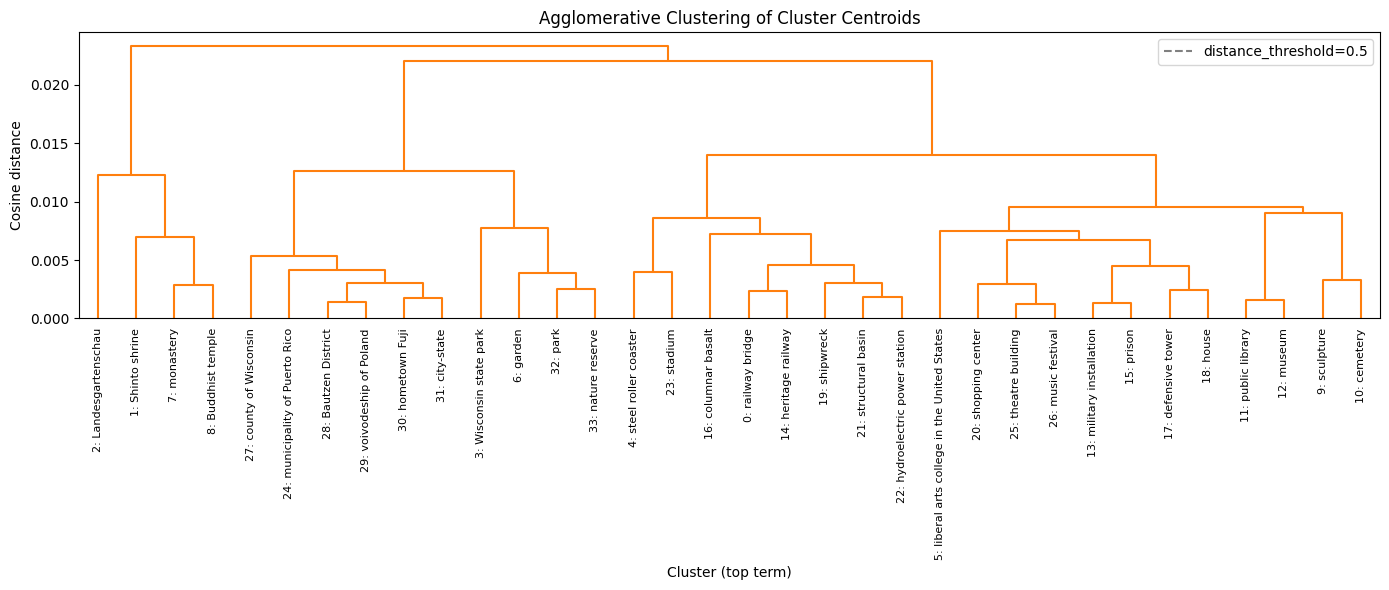

In [153]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


cluster_ids = sorted(cid for cid in np.unique(clusterer.labels_) if cid >= 0)

top_term_by_cluster = {
    row["labels"]: row["tags"][0] for row in cluster_summary.to_dicts()
}
leaf_labels = [f"{cid}: {top_term_by_cluster[cid]}" for cid in cluster_ids]

plt.figure(figsize=(14, 6))
plot_dendrogram(aggcluster, labels=leaf_labels, color_threshold=0.5)
plt.axhline(y=0.5, color="gray", linestyle="--", label="distance_threshold=0.5")
plt.xlabel("Cluster (top term)")
plt.ylabel("Cosine distance")
plt.title("Agglomerative Clustering of Cluster Centroids")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
tune_hdbscan(centroid_embeddings, MIN_CLUSTER_SIZES)

Min Cluster Size: 5 -> DBCV: 0.190, Clusters: 2, Noise: 37.65%
Min Cluster Size: 10 -> DBCV: 0.175, Clusters: 2, Noise: 48.24%
Min Cluster Size: 15 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%
Min Cluster Size: 20 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%
Min Cluster Size: 25 -> DBCV: 0.000, Clusters: 0, Noise: 100.00%


min_cluster_size,dbcv,n_clusters,noise_ratio
i64,f64,i64,f64
5,0.189716,2,37.647059
10,0.175136,2,48.235294
15,0.0,0,100.0
20,0.0,0,100.0
25,0.0,0,100.0


In [78]:
import hdbscan
import numpy as np

r_tag_embeddings_f64 = r_tag_embeddings.astype("float64")

for size in [5, 10] + list(range(11, 20)) + [20, 25, 50, 100]:
    clusterer = HDBSCAN(min_cluster_size=size).fit(r_tag_embeddings_f64)
    labels = clusterer.labels_
    score = hdbscan.validity.validity_index(r_tag_embeddings_f64, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1) * 100
    print(
        f"Min Cluster Size: {size} -> DBCV: {score:.3f}, "
        f"Clusters: {n_clusters}, Noise: {noise_ratio:.2f}%"
    )

Min Cluster Size: 5 -> DBCV: 0.364, Clusters: 184, Noise: 30.58%
Min Cluster Size: 10 -> DBCV: 0.342, Clusters: 85, Noise: 30.52%
Min Cluster Size: 11 -> DBCV: 0.355, Clusters: 78, Noise: 31.70%
Min Cluster Size: 12 -> DBCV: 0.357, Clusters: 72, Noise: 31.32%
Min Cluster Size: 13 -> DBCV: 0.348, Clusters: 68, Noise: 33.77%
Min Cluster Size: 14 -> DBCV: 0.362, Clusters: 63, Noise: 32.87%
Min Cluster Size: 15 -> DBCV: 0.346, Clusters: 57, Noise: 35.22%
Min Cluster Size: 16 -> DBCV: 0.341, Clusters: 51, Noise: 36.12%
Min Cluster Size: 17 -> DBCV: 0.358, Clusters: 50, Noise: 36.71%
Min Cluster Size: 18 -> DBCV: 0.351, Clusters: 48, Noise: 37.02%
Min Cluster Size: 19 -> DBCV: 0.345, Clusters: 45, Noise: 37.63%
Min Cluster Size: 20 -> DBCV: 0.331, Clusters: 45, Noise: 38.57%
Min Cluster Size: 25 -> DBCV: 0.334, Clusters: 34, Noise: 38.39%
Min Cluster Size: 50 -> DBCV: 0.315, Clusters: 15, Noise: 41.11%
Min Cluster Size: 100 -> DBCV: 0.271, Clusters: 6, Noise: 59.75%


In [86]:
clusterer = HDBSCAN(min_cluster_size=25, prediction_data=True).fit(
    r_tag_embeddings.astype("float64")
)
cluster_labels = clusterer.labels_

# to predict cluster membership for NEW/unseen points later:
# new_labels, strengths = hdbscan.approximate_predict(clusterer, new_points.astype("float64"))

In [ ]:
df_tags_cluster, cluster_summary = inspect_clusters(tags, clusterer)

#### BERTopic

In [ ]:
from bertopic import BERTopic

tm = BERTopic(
    # language="multilingual",
    min_topic_size=25,
    # hdbscan_model=HDBSCAN(min_cluster_size=25),
    umap_model=UMAP(metric="cosine", n_components=15, random_state=42),
    # hdbscan_model=tune_results[1]["clf"],
    # umap_model=reductor,
    embedding_model=SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    ).to(DEVICE),
    n_gram_range=(1, 3),
)
topics, probs = tm.fit_transform(tags)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
tags_df = pl.DataFrame({"tags": tags, "cluster": topics, "probability": probs})

summary = (
    tags_df.filter(pl.col("cluster") != -1)
    .group_by("cluster")
    .agg(pl.len().alias("size"))
)

top_tags = (
    tags_df.filter(pl.col("cluster") != -1)
    .sort("probability", descending=True)
    .group_by("cluster", maintain_order=True)
    .agg(pl.col("tags").head(20))
)

cluster_summary = summary.join(top_tags, on="cluster")

for row in cluster_summary.sort("cluster").to_dicts():
    print(f"Cluster {row['cluster']} | size={row['size']}")
    print(row["tags"])
    print("-" * 10)

Cluster 0 | size=708
['tumulus', 'lido', 'fort', 'menhir', 'cape', 'basin', 'one-thousander', 'point', 'commandry', 'maar', 'mine', 'Vionnaz', 'velodrome', 'fortune-telling', 'Simultaneum', 'masia', 'dolmen', 'funicular', 'jingū', 'oratory']
----------
Cluster 1 | size=227
['church building', 'minor basilica', 'Catholic parish church', 'Jesuit church', 'Catholic church building', 'Protestant church building', 'Catholic cathedral', 'Rectory to the Reformed Church', 'Greek Catholic church', 'fieldstone church', 'Pius XII', 'clergy house', 'secularized church', 'basilica', 'filial church', 'Roman Catholic ecclesiastical province', 'former church building', 'Catholic pilgrimage church', 'national Church', 'diocese of the Catholic Church']
----------
Cluster 2 | size=186
['nature reserve', 'National Wildlife Refuge', 'national park of Thailand', 'national park', 'National Historical Park', 'US Wilderness Area', 'natural park', 'Naturschutzgebiet', 'National Recreation Area', 'National Park 

In [15]:
import requests
from tqdm.auto import tqdm

OLLAMA_HOST = "http://localhost:11434"
OLLAMA_MODEL = "qwen3.5:latest"

KEYWORD_SYSTEM_PROMPT = (
    'You are labeling clusters of Wikidata landmark/place "instance of" tags '
    "for a landmark-type taxonomy. You will be given a list of short tags that "
    "were grouped together because their embeddings are similar.\n\n"
    "Your job: propose up to 3 candidate NOUNS that could each name the "
    "landmark TYPE shared by most of the tags — the kind of place or structure "
    "they describe, not their location, era, style, or administrative status. "
    "A human will pick the best one from your candidates, so give distinct, "
    "genuinely different options rather than near-duplicates of the same word.\n\n"
    "Rules:\n"
    "1. Each candidate should be ONE word if possible; use a second word only "
    'if one word would be ambiguous or wrong (e.g. "state park").\n'
    "2. Singular form, lowercase, no punctuation.\n"
    "3. Order candidates from most to least representative/confident.\n"
    "4. Prefer common, general English terms — not rare synonyms, not overly "
    "specific subtypes, not proper nouns.\n"
    "5. If the tags mainly describe an administrative or geographic entity "
    "rather than a landmark type, or are too unrelated to share any single "
    "type, respond with exactly: OTHER\n"
    "6. Output ONLY the candidates, one per line, nothing else — no numbering, "
    "no explanation, no punctuation."
)

FEW_SHOT_EXAMPLES = [
    (
        "defensive tower, observation tower, fortified tower, tower, communication "
        "tower, Irish round tower, lattice tower, coastal tower, fire lookout tower, "
        "Leaning Tower of Pisa",
        ["tower", "watchtower", "lookout"],
    ),
    (
        "Wisconsin state park, California state park, Washington state park, "
        "state park, Kentucky state park, Arkansas state park",
        ["state park", "park", "protected area"],
    ),
    (
        "county of Wisconsin, county of Tennessee, county seat, Humboldt County, "
        "registration county, county of Nevada, county of Oregon",
        # ["county", "administrative division", "district"],
        ["other"],
    ),
    (
        "Landesgartenschau, Rathaus, Naturschutzgebiet, Shikinaisha, Betsu-gū, "
        "Kōtai Jingū, Itsukushima, jingū, chokusaisha",
        ["shrine", "civic building", "garden"],
    ),
]

FEW_SHOT_MESSAGES = [{"role": "system", "content": KEYWORD_SYSTEM_PROMPT}]
for _tags, _keyword in FEW_SHOT_EXAMPLES:
    FEW_SHOT_MESSAGES.append({"role": "user", "content": f"Tags: {_tags}"})
    FEW_SHOT_MESSAGES.append({"role": "assistant", "content": ",".join(_keyword)})


def generate_cluster_keyword(
    tags: list[str], model: str = OLLAMA_MODEL, retries: int = 3
) -> str:
    tag_list = ", ".join(tags)
    payload = {
        "model": model,
        "messages": FEW_SHOT_MESSAGES
        + [{"role": "user", "content": f"Tags: {tag_list}"}],
        "think": False,
        "stream": False,
        "options": {"temperature": 0, "num_predict": 50},
    }
    for attempt in range(retries):
        try:
            resp = requests.post(f"{OLLAMA_HOST}/api/chat", json=payload, timeout=1800)
            resp.raise_for_status()
            keyword = resp.json()["message"]["content"].strip()
            if keyword:
                return keyword
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed to generate keyword for tags [{tag_list[:50]}...]: {e}")
                return "unknown"
    return "unknown"


cluster_keywords = {}
for row in tqdm(
    cluster_summary.sort("cluster").to_dicts(), desc="Generating cluster keywords"
):
    cluster_keywords[row["cluster"]] = generate_cluster_keyword(row["tags"])

Generating cluster keywords:   0%|          | 0/41 [00:00<?, ?it/s]

In [19]:
cluster_summary = cluster_summary.with_columns(
    pl.col("cluster")
    .map_elements(lambda l: cluster_keywords.get(l, "unknown"), return_dtype=pl.Utf8)
    .alias("representative_keyword")
)

cluster_summary.sort("cluster")

cluster,size,tags,representative_keyword
i64,u32,list[str],str
0,708,"[""tumulus"", ""lido"", … ""oratory""]","""landmark,structure,site"""
1,227,"[""church building"", ""minor basilica"", … ""diocese of the Catholic Church""]","""church,building,cathedral"""
2,186,"[""nature reserve"", ""National Wildlife Refuge"", … ""national nature reserve""]","""nature reserve,national park,p…"
3,175,"[""fish pond"", ""waterfall"", … ""natural gas field""]","""water feature,water body,water…"
4,159,"[""neighborhood"", ""neighborhood of Washington"", … ""neighborhood in Queens""]","""neighborhood,city,town"""
…,…,…,…
36,29,"[""steel roller coaster"", ""Ferris wheel"", … ""log flume ride""]","""amusement ride,roller coaster,…"
37,28,"[""sculpture trail"", ""sculpture series"", … ""sculpture gathering""]","""sculpture,statue,monument"""
38,28,"[""private housing estate in Hong Kong"", ""prefecture-level city of China"", … ""districts of Hong Kong""]","""administrative territorial ent…"


In [21]:
cluster_summary.with_columns(pl.col("tags").list.join(",")).sort("cluster").write_csv(
    "./wikidata_tags_coarse.csv"
)

In [201]:
tags_df.write_csv("./tags_to_cluster.csv")

#### Tag Analysis Coverage

In [4]:
tags_df = pl.read_csv("./tags_to_cluster.csv")
human_tag_df = pl.read_csv("./wikidata_tags_coarse_human_val.csv")
tags_df = tags_df.join(human_tag_df.select(["cluster", "valid_tag"]), on="cluster")

tags2cluster = {
    item["tags"]: item["valid_tag"]
    for item in tags_df.select(["tags", "valid_tag"]).to_dicts()
}
tags2clusterid = {
    item["tags"]: item["cluster"]
    for item in tags_df.select(["tags", "cluster"]).to_dicts()
}

In [5]:
df_tag_clean = df_tag_clean.with_columns(
    pl.col("instance_tag_clean")
    .list.eval(
        pl.element().replace_strict(tags2cluster, default=None, return_dtype=pl.String)
    )
    .alias("category")
).with_columns(
    pl.col("instance_tag_clean")
    .list.eval(
        pl.element().replace_strict(
            tags2clusterid, default=-1, return_dtype=pl.Int64
        )
    )
    .alias("cluster_id")
)

In [ ]:
df_tag_clean = df_tag_clean.with_columns(
    pl.col("category")
    .list.eval(pl.element().filter(pl.element() != "other").drop_nulls())
    .list.unique()
)#.filter(pl.col("category").list.len() > 0)

In [6]:
landmark_cluster_summary = (
    df_tag_clean.explode("cluster_id")
    .filter(pl.col("cluster_id").is_not_null())
    .group_by("landmark_id")
    .agg(pl.col("cluster_id").unique().alias("unique_cluster_ids"))
    .with_columns(pl.col("unique_cluster_ids").list.len().alias("n_unique"))
)

n_total = landmark_cluster_summary.height

n_noise_only = landmark_cluster_summary.filter(
    (pl.col("n_unique") == 1) & (pl.col("unique_cluster_ids").list.first() == -1)
).height

n_single_clustered = landmark_cluster_summary.filter(
    (pl.col("n_unique") == 1) & (pl.col("unique_cluster_ids").list.first() != -1)
).height

n_multi = landmark_cluster_summary.filter(pl.col("n_unique") > 1).height

print(f"Total landmark_id: {n_total}")
print(
    f"Noise only (single cluster id == -1): {n_noise_only} ({n_noise_only / n_total * 100:.2f}%)"
)
print(
    f"Single non-noise cluster: {n_single_clustered} ({n_single_clustered / n_total * 100:.2f}%)"
)
print(f"Multiple distinct cluster ids: {n_multi} ({n_multi / n_total * 100:.2f}%)")


Total landmark_id: 125975
Noise only (single cluster id == -1): 14889 (11.82%)
Single non-noise cluster: 66464 (52.76%)
Multiple distinct cluster ids: 44622 (35.42%)


In [7]:
row_cluster_summary = (
    df_tag_clean.with_columns(
        pl.col("cluster_id").list.drop_nulls().list.unique().alias("unique_cluster_ids")
    )
    .filter(pl.col("unique_cluster_ids").list.len() > 0)
    .with_columns(
        pl.col("unique_cluster_ids")
        .list.eval(pl.element().filter(pl.element() != -1))
        .alias("non_noise_ids")
    )
    .with_columns(pl.col("non_noise_ids").list.len().alias("n_non_noise"))
    .with_columns(
        pl.when(pl.col("n_non_noise") == 0)
        .then(pl.lit("noise_only"))
        .when(pl.col("n_non_noise") == 1)
        .then(pl.lit("single_non_noise"))
        .otherwise(pl.lit("multi_distinct"))
        .alias("category")
    )
    .with_columns(pl.col("country").fill_null("Unknown"))
)

n_total = row_cluster_summary.height
for cat in ["noise_only", "single_non_noise", "multi_distinct"]:
    n = row_cluster_summary.filter(pl.col("category") == cat).height
    print(f"{cat}: {n} ({n / n_total * 100:.2f}%)")

noise_only: 522307 (14.42%)
single_non_noise: 2578170 (71.15%)
multi_distinct: 522857 (14.43%)


In [8]:
country_cluster_dist = (
    row_cluster_summary.group_by(["country", "category"])
    .agg(pl.len().alias("count"))
    .pivot(values="count", index="country", on="category")
    .fill_null(0)
)

for col in ["noise_only", "single_non_noise", "multi_distinct"]:
    if col not in country_cluster_dist.columns:
        country_cluster_dist = country_cluster_dist.with_columns(pl.lit(0).alias(col))

country_cluster_dist = (
    country_cluster_dist.with_columns(
        (
            pl.col("noise_only") + pl.col("single_non_noise") + pl.col("multi_distinct")
        ).alias("total")
    )
    .with_columns(
        [
            (pl.col("noise_only") / pl.col("total") * 100)
            .round(2)
            .alias("noise_only_pct"),
            (pl.col("single_non_noise") / pl.col("total") * 100)
            .round(2)
            .alias("single_non_noise_pct"),
            (pl.col("multi_distinct") / pl.col("total") * 100)
            .round(2)
            .alias("multi_distinct_pct"),
        ]
    )
    .sort("total", descending=True)
)

country_cluster_dist

country,noise_only,single_non_noise,multi_distinct,total,noise_only_pct,single_non_noise_pct,multi_distinct_pct
str,u32,u32,u32,u32,f64,f64,f64
"""United States""",62637,349205,41111,452953,13.83,77.1,9.08
"""Germany""",62822,290357,36057,389236,16.14,74.6,9.26
"""United Kingdom""",35968,219195,40748,295911,12.16,74.07,13.77
"""France""",44909,172178,21547,238634,18.82,72.15,9.03
"""Spain""",24208,99943,28234,152385,15.89,65.59,18.53
…,…,…,…,…,…,…,…
"""Tuvalu""",0,4,0,4,0.0,100.0,0.0
"""Saint Barthélemy""",0,3,0,3,0.0,100.0,0.0
"""Solomon Islands""",0,2,0,2,0.0,100.0,0.0
